In [1]:
import os
import time
import copy
import torch
import shutil
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn, optim
import torch.nn.functional as F
from model_utils import (
    combine_datasets,
    split_dataset,
    count_images_in_directory,
    copy_images
)

In [5]:
# Define transforms for training, validation, and testing
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

valid_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Paths for the datasets
original_dataset_dir = '/workspace/archive/Lumpy Skin Images Dataset'
combined_dataset_dir = '/workspace/archive/combined_dataset'

# Load the original datasets (Normal and Lumpy Skin)
original_normal_skin_dir = os.path.join(original_dataset_dir, 'Normal Skin')
original_lumpy_skin_dir = os.path.join(original_dataset_dir, 'Lumpy Skin')

# Load the combined datasets (Normal and Lumpy Skin)
combined_normal_skin_dir = os.path.join(combined_dataset_dir, 'Normal Skin')
combined_lumpy_skin_dir = os.path.join(combined_dataset_dir, 'Lumpy Skin')

# Define the original datasets using ImageFolder with transformations for training
original_train_dataset = datasets.ImageFolder(root=original_dataset_dir, transform=train_transforms)
original_valid_dataset = datasets.ImageFolder(root=original_dataset_dir, transform=valid_transforms)
combined_train_dataset = datasets.ImageFolder(root=combined_dataset_dir, transform=train_transforms)
combined_valid_dataset = datasets.ImageFolder(root=combined_dataset_dir, transform=valid_transforms)

# Create DataLoaders for both original and combined datasets
original_train_loader = DataLoader(original_train_dataset, batch_size=32, shuffle=True)
original_valid_loader = DataLoader(original_valid_dataset, batch_size=32, shuffle=False)
combined_train_loader = DataLoader(combined_train_dataset, batch_size=32, shuffle=True)
combined_valid_loader = DataLoader(combined_valid_dataset, batch_size=32, shuffle=False)

# Define test dataset for original and combined datasets separately
original_test_dataset = datasets.ImageFolder(root=original_dataset_dir, transform=valid_transforms)
combined_test_dataset = datasets.ImageFolder(root=combined_dataset_dir, transform=valid_transforms)

# Create DataLoaders for the original and combined test datasets
original_test_loader = DataLoader(original_test_dataset, batch_size=32, shuffle=False)
combined_test_loader = DataLoader(combined_test_dataset, batch_size=32, shuffle=False)

print("Original Dataset (Training):")
print(f"Number of batches: {len(original_train_loader)}")
for images, labels in original_train_loader:
    print(f"Image batch size: {images.size()}")
    break

print("\nCombined Dataset (Training):")
print(f"Number of batches: {len(combined_train_loader)}")
for images, labels in combined_train_loader:
    print(f"Image batch size: {images.size()}")
    break


print("\nOriginal Dataset (Validation):")
print(f"Number of batches: {len(original_valid_loader)}")
for images, labels in original_valid_loader:
    print(f"Image batch size: {images.size()}")
    break

print("\nCombined Dataset (Validation):")
print(f"Number of batches: {len(combined_valid_loader)}")
for images, labels in combined_valid_loader:
    print(f"Image batch size: {images.size()}")
    break

print("\nOriginal Dataset (Test):")
print(f"Number of batches: {len(original_test_loader)}")
for images, labels in original_test_loader:
    print(f"Image batch size: {images.size()}")
    break

print("\nCombined Dataset (Test):")
print(f"Number of batches: {len(combined_test_loader)}")
for images, labels in combined_test_loader:
    print(f"Image batch size: {images.size()}")
    break


Original Dataset (Training):
Number of batches: 34
Image batch size: torch.Size([32, 3, 256, 256])

Combined Dataset (Training):
Number of batches: 76
Image batch size: torch.Size([32, 3, 256, 256])

Original Dataset (Validation):
Number of batches: 34
Image batch size: torch.Size([32, 3, 256, 256])

Combined Dataset (Validation):
Number of batches: 76
Image batch size: torch.Size([32, 3, 256, 256])

Original Dataset (Test):
Number of batches: 34
Image batch size: torch.Size([32, 3, 256, 256])

Combined Dataset (Test):
Number of batches: 76
Image batch size: torch.Size([32, 3, 256, 256])


In [6]:
!pip install efficientnet-pytorch


In [7]:
import torch.nn as nn
from efficientnet_pytorch import EfficientNet

class XceptionModel(nn.Module):
    def __init__(self, num_classes=2):
        super(XceptionModel, self).__init__()

        # Load the pre-trained EfficientNet-B0 model
        self.base_model = EfficientNet.from_pretrained('efficientnet-b0')

        
        for param in self.base_model.parameters():
            param.requires_grad = False

        
        in_features = self.base_model._fc.in_features
        self.base_model._fc = nn.Identity()

        
        self.fc1 = nn.Linear(in_features, 1024)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(1024, num_classes)
        self.dropout = nn.Dropout(0.15)

    def forward(self, x):
        
        x = self.base_model(x)
        x = x.view(x.size(0), -1) 

        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x


In [8]:
from torchsummary import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instantiate the model
custom_model = XceptionModel(num_classes=2).to(device)  

input_tensor = torch.randn(1, 3, 256, 256).to(device)  
summary(custom_model, (3, 256, 256))



Loaded pretrained weights for efficientnet-b0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         ZeroPad2d-1          [-1, 3, 257, 257]               0
Conv2dStaticSamePadding-2         [-1, 32, 128, 128]             864
       BatchNorm2d-3         [-1, 32, 128, 128]              64
MemoryEfficientSwish-4         [-1, 32, 128, 128]               0
         ZeroPad2d-5         [-1, 32, 130, 130]               0
Conv2dStaticSamePadding-6         [-1, 32, 128, 128]             288
       BatchNorm2d-7         [-1, 32, 128, 128]              64
MemoryEfficientSwish-8         [-1, 32, 128, 128]               0
          Identity-9             [-1, 32, 1, 1]               0
Conv2dStaticSamePadding-10              [-1, 8, 1, 1]             264
MemoryEfficientSwish-11              [-1, 8, 1, 1]               0
         Identity-12              [-1, 8, 1, 1]               0
Conv2dStaticSamePadding-13        

In [9]:

learning_rate = 1e-4  
batch_size = 32

optimizer = optim.Adam(custom_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# Initialize history trackers
original_train_loss_history = []
original_train_accuracy_history = []
original_valid_loss_history = []
original_valid_accuracy_history = []

combined_train_loss_history = []
combined_train_accuracy_history = []
combined_valid_loss_history = []
combined_valid_accuracy_history = []

# Set the directory to save models
model_dir = "./models7"
os.makedirs(model_dir, exist_ok=True)

def train_phase(train_loader, model, optimizer, criterion, dataset_name="Train"):
    model.train()  
    running_train_loss = 0.0
    correct_train_predictions = 0
    total_train_predictions = 0

    for inputs, labels in train_loader:
        
        inputs, labels = inputs.to(device), labels.to(device)
        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        # Track the loss and accuracy
        running_train_loss += loss.item() * inputs.size(0) 
        _, predicted = torch.max(outputs, 1)
        correct_train_predictions += (predicted == labels).sum().item()
        total_train_predictions += labels.size(0)

    # Compute the training accuracy and loss
    train_acc = correct_train_predictions / total_train_predictions
    train_loss = running_train_loss / len(train_loader.dataset)
    
    if dataset_name == "Original":
        original_train_loss_history.append(train_loss)
        original_train_accuracy_history.append(train_acc)
    else:
        combined_train_loss_history.append(train_loss)
        combined_train_accuracy_history.append(train_acc)
    

    print(f"{dataset_name} Phase: Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
    
    return train_loss, train_acc


def validation_phase(valid_loader, model, criterion, dataset_name="Validation"):
    model.eval()  
    running_valid_loss = 0.0
    correct_valid_predictions = 0
    total_valid_predictions = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            
            running_valid_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_valid_predictions += (predicted == labels).sum().item()
            total_valid_predictions += labels.size(0)

    valid_acc = correct_valid_predictions / total_valid_predictions
    valid_loss = running_valid_loss / len(valid_loader.dataset)
    
    if dataset_name == "Original":
        original_valid_loss_history.append(valid_loss)
        original_valid_accuracy_history.append(valid_acc)
    else:
        combined_valid_loss_history.append(valid_loss)
        combined_valid_accuracy_history.append(valid_acc)
    

    print(f"{dataset_name} Phase: Loss: {valid_loss:.4f}, Accuracy: {valid_acc:.4f}")
    
    return valid_loss, valid_acc


def train_model(train_loader, valid_loader, model, optimizer, criterion, epochs=30, patience=5, dataset_name="Original"):
    """
    Main training loop for training the model.
    """
    best_model_wts = copy.deepcopy(model.state_dict())  
    best_val_acc = 0.0
    early_stop_counter = 0

    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs} - Dataset: {dataset_name}")

        start_time = time.time()

        # Train phase
        train_loss, train_acc = train_phase(train_loader, model, optimizer, criterion, dataset_name)

        # Validation phase
        valid_loss, valid_acc = validation_phase(valid_loader, model, criterion, dataset_name)

        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
        print(f"Validation Loss: {valid_loss:.4f}, Validation Accuracy: {valid_acc:.4f}")

        if valid_acc > best_val_acc:
            print(f"Validation accuracy improved from {best_val_acc:.4f} to {valid_acc:.4f}. Saving model.")
            best_val_acc = valid_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            model_path = os.path.join(model_dir, f"{dataset_name}_model_{epoch + 1:02d}-{valid_acc:.4f}.pth")
            torch.save(model.state_dict(), model_path)
            early_stop_counter = 0 
        else:
            print(f"Validation accuracy did not improve from {best_val_acc:.4f}")
            early_stop_counter += 1

        # Early Stopping
        if early_stop_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs.")
            break

        epoch_time = time.time() - start_time
        print(f"Epoch {epoch + 1} completed in {epoch_time:.2f} seconds.")

    model.load_state_dict(best_model_wts)

    return model, best_val_acc


In [10]:
custom_model, best_val_acc_original = train_model(
    original_train_loader, 
    original_valid_loader, 
    custom_model, 
    optimizer, 
    criterion, 
    dataset_name="Original"
)



Epoch 1/30 - Dataset: Original
Original Phase: Loss: 0.5754, Accuracy: 0.6728
Original Phase: Loss: 0.5295, Accuracy: 0.6985
Train Loss: 0.5754, Train Accuracy: 0.6728
Validation Loss: 0.5295, Validation Accuracy: 0.6985
Validation accuracy improved from 0.0000 to 0.6985. Saving model.
Epoch 1 completed in 7.35 seconds.

Epoch 2/30 - Dataset: Original
Original Phase: Loss: 0.4337, Accuracy: 0.8263
Original Phase: Loss: 0.4182, Accuracy: 0.7803
Train Loss: 0.4337, Train Accuracy: 0.8263
Validation Loss: 0.4182, Validation Accuracy: 0.7803
Validation accuracy improved from 0.6985 to 0.7803. Saving model.
Epoch 2 completed in 6.44 seconds.

Epoch 3/30 - Dataset: Original
Original Phase: Loss: 0.3461, Accuracy: 0.8658
Original Phase: Loss: 0.3098, Accuracy: 0.8686
Train Loss: 0.3461, Train Accuracy: 0.8658
Validation Loss: 0.3098, Validation Accuracy: 0.8686
Validation accuracy improved from 0.7803 to 0.8686. Saving model.
Epoch 3 completed in 6.39 seconds.

Epoch 4/30 - Dataset: Original

In [11]:
custom_model_combined, best_val_acc_combined = train_model(
    combined_train_loader, 
    combined_valid_loader, 
    custom_model, 
    optimizer, 
    criterion, 
    dataset_name="Combined"
)


Epoch 1/30 - Dataset: Combined
Combined Phase: Loss: 0.3320, Accuracy: 0.8627
Combined Phase: Loss: 0.2406, Accuracy: 0.9180
Train Loss: 0.3320, Train Accuracy: 0.8627
Validation Loss: 0.2406, Validation Accuracy: 0.9180
Validation accuracy improved from 0.0000 to 0.9180. Saving model.
Epoch 1 completed in 17.13 seconds.

Epoch 2/30 - Dataset: Combined
Combined Phase: Loss: 0.2871, Accuracy: 0.8772
Combined Phase: Loss: 0.2161, Accuracy: 0.9201
Train Loss: 0.2871, Train Accuracy: 0.8772
Validation Loss: 0.2161, Validation Accuracy: 0.9201
Validation accuracy improved from 0.9180 to 0.9201. Saving model.
Epoch 2 completed in 16.52 seconds.

Epoch 3/30 - Dataset: Combined
Combined Phase: Loss: 0.2461, Accuracy: 0.8935
Combined Phase: Loss: 0.2170, Accuracy: 0.9164
Train Loss: 0.2461, Train Accuracy: 0.8935
Validation Loss: 0.2170, Validation Accuracy: 0.9164
Validation accuracy did not improve from 0.9201
Epoch 3 completed in 16.58 seconds.

Epoch 4/30 - Dataset: Combined
Combined Phase

In [12]:
# Training phase on Original Dataset
train_loss_original, train_accuracy_original = train_phase(
    train_loader=original_train_loader, 
    model=custom_model, 
    optimizer=optimizer, 
    criterion=criterion, 
    dataset_name="Original"
)

# Validation phase on Original Dataset
valid_loss_original, valid_accuracy_original = validation_phase(
    valid_loader=original_valid_loader, 
    model=custom_model, 
    criterion=criterion, 
    dataset_name="Original"
)

# Training phase on Combined Dataset
train_loss_combined, train_accuracy_combined = train_phase(
    train_loader=combined_train_loader, 
    model=custom_model, 
    optimizer=optimizer, 
    criterion=criterion, 
    dataset_name="Combined"
)

# Validation phase on Combined Dataset
valid_loss_combined, valid_accuracy_combined = validation_phase(
    valid_loader=combined_valid_loader, 
    model=custom_model, 
    criterion=criterion, 
    dataset_name="Combined"
)

# Test phase for Original Dataset
test_loss_original, test_acc_original = validation_phase(
    valid_loader=original_test_loader,
    model=custom_model,
    criterion=criterion,
    dataset_name="Original Test"
)

# Test phase for Combined Dataset
test_loss_combined, test_acc_combined = validation_phase(
    valid_loader=combined_test_loader,
    model=custom_model,
    criterion=criterion,
    dataset_name="Combined Test"
)

# Print the results
print(f"--- Original Dataset ---")
print(f"Training Loss: {train_loss_original:.4f}, Training Accuracy: {train_accuracy_original:.4f}")
print(f"Validation Loss: {valid_loss_original:.4f}, Validation Accuracy: {valid_accuracy_original:.4f}")
print(f"Test Loss: {test_loss_original:.4f}, Test Accuracy: {test_acc_original:.4f}")

print(f"\n--- Combined Dataset ---")
print(f"Training Loss: {train_loss_combined:.4f}, Training Accuracy: {train_accuracy_combined:.4f}")
print(f"Validation Loss: {valid_loss_combined:.4f}, Validation Accuracy: {valid_accuracy_combined:.4f}")
print(f"Test Loss: {test_loss_combined:.4f}, Test Accuracy: {test_acc_combined:.4f}")


Original Phase: Loss: 0.2439, Accuracy: 0.9053
Original Phase: Loss: 0.2612, Accuracy: 0.8842
Combined Phase: Loss: 0.2145, Accuracy: 0.9151
Combined Phase: Loss: 0.1475, Accuracy: 0.9521
Original Test Phase: Loss: 0.1873, Accuracy: 0.9283
Combined Test Phase: Loss: 0.1475, Accuracy: 0.9521
--- Original Dataset ---
Training Loss: 0.2439, Training Accuracy: 0.9053
Validation Loss: 0.2612, Validation Accuracy: 0.8842
Test Loss: 0.1873, Test Accuracy: 0.9283

--- Combined Dataset ---
Training Loss: 0.2145, Training Accuracy: 0.9151
Validation Loss: 0.1475, Validation Accuracy: 0.9521
Test Loss: 0.1475, Test Accuracy: 0.9521


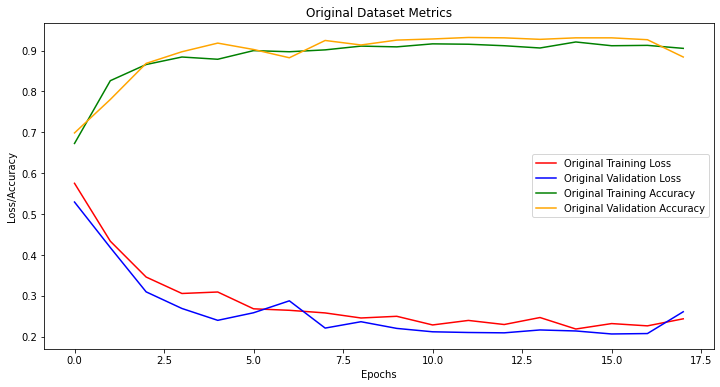

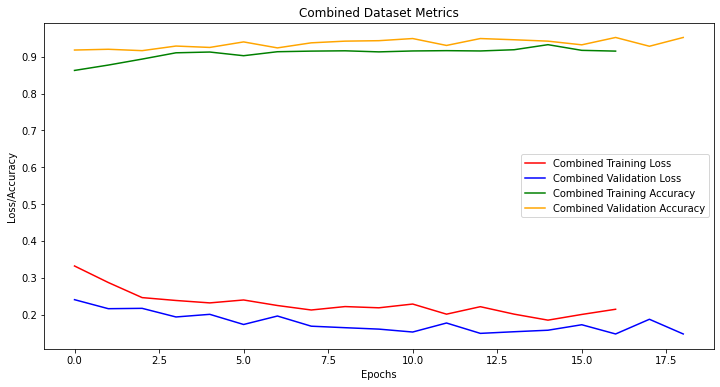

In [13]:
# Plot for original dataset
plt.figure(figsize=(12, 6))
plt.plot(original_train_loss_history, label="Original Training Loss", color='red')
plt.plot(original_valid_loss_history, label="Original Validation Loss", color='blue')
plt.plot(original_train_accuracy_history, label="Original Training Accuracy", color='green')
plt.plot(original_valid_accuracy_history, label="Original Validation Accuracy", color='orange')
plt.title("Original Dataset Metrics")
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

# Plot for combined dataset
plt.figure(figsize=(12, 6))
plt.plot(combined_train_loss_history, label="Combined Training Loss", color='red')
plt.plot(combined_valid_loss_history, label="Combined Validation Loss", color='blue')
plt.plot(combined_train_accuracy_history, label="Combined Training Accuracy", color='green')
plt.plot(combined_valid_accuracy_history, label="Combined Validation Accuracy", color='orange')
plt.title("Combined Dataset Metrics")
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()


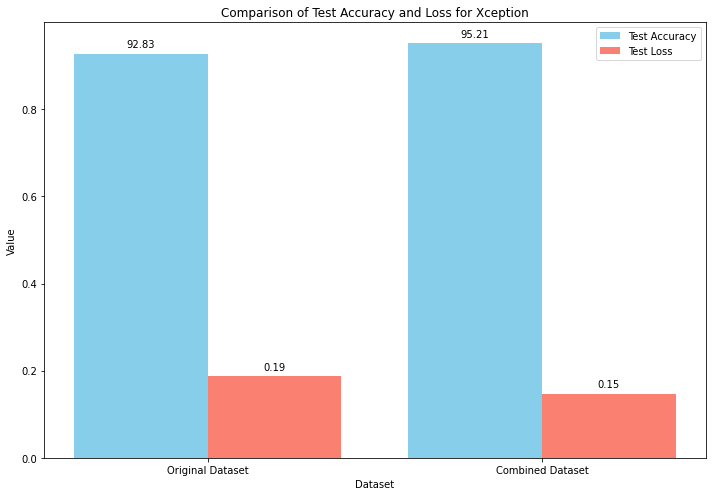

In [14]:
# Test accuracy and loss values
test_acc_values = [test_acc_original, test_acc_combined]
test_loss_values = [test_loss_original, test_loss_combined]

# Dataset labels
datasets = ['Original Dataset', 'Combined Dataset']

x = np.arange(len(datasets))  
bar_width = 0.4  

fig, ax = plt.subplots(figsize=(10, 7))

# Plot Test Accuracy bars
bars1 = ax.bar(x - bar_width/2, test_acc_values, bar_width, label='Test Accuracy', color='skyblue')

# Plot Test Loss bars
bars2 = ax.bar(x + bar_width/2, test_loss_values, bar_width, label='Test Loss', color='salmon')

for bar, value in zip(bars1, test_acc_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.01,  
        f'{value * 100:.2f}',  
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

for bar, value in zip(bars2, test_loss_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.01,  
        f'{value:.2f}',  
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

ax.set_xlabel('Dataset')
ax.set_ylabel('Value')
ax.set_title('Comparison of Test Accuracy and Loss for Xception')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()

plt.tight_layout()
plt.show()


In [15]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

true_1, preds_1, probs_1 = evaluate_model(custom_model, original_test_loader, "Original", device)
true_2, preds_2, probs_2 = evaluate_model(custom_model, combined_test_loader, "Combined", device)



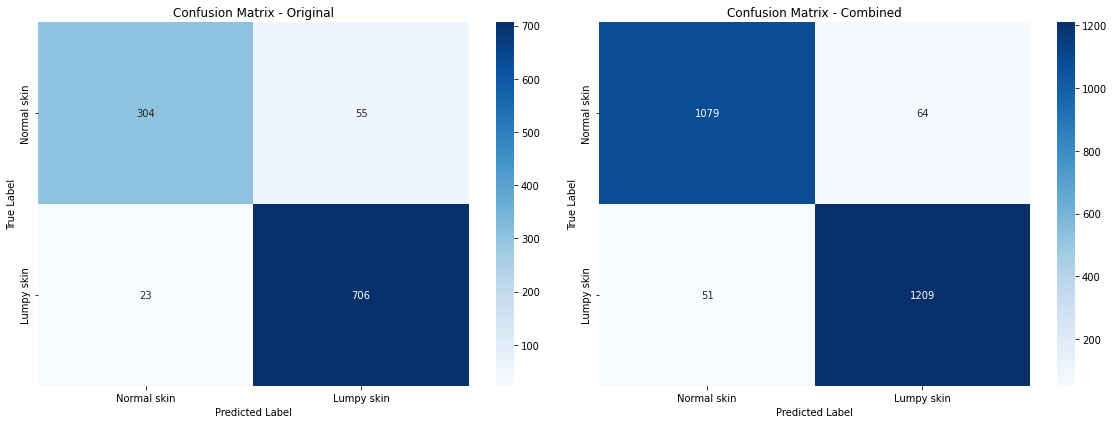

In [16]:
# Plot Confusion Matrices
plot_confusion_matrices(true_1, preds_1, "Original", true_2, preds_2, "Combined")


In [17]:
print_metrics(true_1, preds_1, "Original", true_2, preds_2, "Combined")



Metrics for Original Dataset:
              precision    recall  f1-score   support

 Normal skin       0.93      0.85      0.89       359
  Lumpy skin       0.93      0.97      0.95       729

    accuracy                           0.93      1088
   macro avg       0.93      0.91      0.92      1088
weighted avg       0.93      0.93      0.93      1088

Mean Squared Error (MSE): 0.0717
Error Rate: 7.1691%

Metrics for Combined Dataset:
              precision    recall  f1-score   support

 Normal skin       0.95      0.94      0.95      1143
  Lumpy skin       0.95      0.96      0.95      1260

    accuracy                           0.95      2403
   macro avg       0.95      0.95      0.95      2403
weighted avg       0.95      0.95      0.95      2403

Mean Squared Error (MSE): 0.0479
Error Rate: 4.7857%



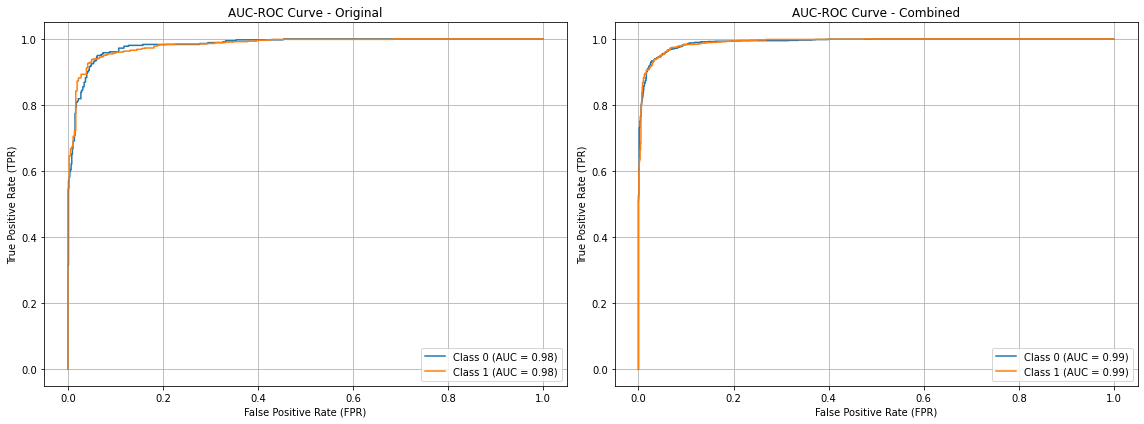

In [18]:
#plot AUC-ROC Curves
plot_auc_roc(true_1, probs_1, "Original", true_2, probs_2, "Combined")
